In [1]:
from preamble_jax import *

Available devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]
CPU devices: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7)]


2025-12-09 23:49:09,805 - WARNING - File .dacerc not found. You are requesting data in public mode. To change this behaviour, create a .dacerc file in your home directory and fill it with your API key. More infos on https://dace.unige.ch
/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/chromatic/imports.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import copy, pkg_resources, os, glob, pickle


In [12]:
def numpyro_model():

    """
    Define the probabilistic model in NUMPYRO
    """
    params = {}

    # Stellar Parameters

    # params[r'$ff_1$'] = numpyro.sample(r'$ff_1$', dist.Uniform(-6,1))
    params[r'$ff_2$'] = numpyro.sample(r'$ff_2$', dist.Uniform(-8,2))
    # params[r'$ff_3$'] = numpyro.sample(r'$ff_3$', dist.Uniform(-6,2))

    # ff_scale_factor = numpyro.sample(r'$ff_{scale_factor}$',dist.Uniform(0, 1))
    # params[r'$ff_2$'] = numpyro.deterministic(r'$ff_2$', params[r'$ff_1$'] * ff_scale_factor )
    # params[r'$ff_3$'] = numpyro.deterministic(r'$ff_3$', 1.0 - params[r'$ff_1$'] - params[r'$ff_2$'])

    # params[r'$ff_1$'] = numpyro.deterministic(r'$ff_1$',  params[r'$ff_1$']/(params[r'$ff_1$']+params[r'$ff_2$']+1.0))
    
    params[r'T$_1$'] = numpyro.sample(r'T$_1$', dist.Uniform(3400, 3600))
    params[r'T$_2$'] = numpyro.sample(r'T$_2$', dist.Uniform(3600, 4700))
    # params[r'T$_3$'] = numpyro.sample(r'T$_3$', dist.Uniform(1100, 3400))

    params['offset_G102'] = numpyro.sample('offset_G102',dist.Uniform(0.0,0.5))
    offset_102 = jnp.asarray(params['offset_G102'],dtype=jnp.float64)

    params[r'$\sigma_{\rm conv}$'] = numpyro.sample(r'$\sigma_{\rm conv}$', dist.LogUniform(0.0001,10.0) )
    
    beta_102 = numpyro.sample(r'$\beta_{\rm G102}$', dist.Uniform(0.0, 3))
    beta_141 = numpyro.sample(r'$\beta_{\rm G141}$', dist.Uniform(0.0, 3))

    'Adjust and concatenate data'
    _spec_flux_jax = jnp.concatenate(
        [
            jnp.array(calibrated_mean_spec_G102+offset_102),
            jnp.array(calibrated_mean_spec_G141)
        ]
    )
    spec_flux_jax = _spec_flux_jax/jnp.mean(_spec_flux_jax)
    spec_err_jax = jnp.concatenate(
        [
            jnp.array((10**beta_102)*oot_spec_err_G102),
            jnp.array((10**beta_141)*oot_spec_err_G141)
        ]
    )
    combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102),jnp.array(SED_wavelengths_G141)])
    
    @jit
    def decomp_model_1T(params,data_wave,**kwargs):

        T_1 = jnp.asarray(params['T$_1$'], dtype=jnp.float64)
        
        spec_1 = get_BTSettl_spectrum_jax(T=T_1)
        
        # Calculate combined spectrum
        _f = spec_1[1]
        _model_flux = ( _f/jnp.mean(_f) )
        convolved = convolve_spectrum_jax( panchromatic_wavelengths, _model_flux, sigma=jnp.asarray(params[r'$\sigma_{\rm conv}$'], dtype=jnp.float64) )
        binned_model_flux = shone.bin_spectrum(data_wave, panchromatic_wavelengths, convolved)
        model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

        return model_flux
    
    @jit
    def decomp_model_2T(params,data_wave,**kwargs):

        f_1 = 1.0
        f_2 = 10**jnp.asarray(params[r'$ff_2$'], dtype=jnp.float64)
        
        T_1 = jnp.asarray(params['T$_1$'], dtype=jnp.float64)
        T_2 = jnp.asarray(params['T$_2$'], dtype=jnp.float64)
        
        spec_1, spec_2 = [
            get_BTSettl_spectrum_jax(T=Temp)
            for Temp in [T_1,T_2] ]
        
        # Calculate combined spectrum
        _f = (f_1*spec_1[1] + f_2*spec_2[1])
        _model_flux = ( _f/jnp.mean(_f) )
        convolved = convolve_spectrum_jax( panchromatic_wavelengths, _model_flux, sigma=jnp.asarray(params[r'$\sigma_{\rm conv}$'], dtype=jnp.float64) )
        binned_model_flux = shone.bin_spectrum(data_wave, panchromatic_wavelengths, convolved)
        model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

        return model_flux
    
    @jit
    def decomp_model_3T(params,data_wave,**kwargs):

        f_1 = 1.0
        f_2 = 10**jnp.asarray(params[r'$ff_2$'], dtype=jnp.float64)
        f_3 = 10**jnp.asarray(params[r'$ff_3$'], dtype=jnp.float64)
        
        T_1 = jnp.asarray(params['T$_1$'], dtype=jnp.float64)
        T_2 = jnp.asarray(params['T$_2$'], dtype=jnp.float64)
        T_3 = jnp.asarray(params['T$_3$'], dtype=jnp.float64)
        
        spec_1, spec_2, spec_3, = [
            get_BTSettl_spectrum_jax(T=Temp)
            for Temp in [T_1,T_2,T_3] ]
        
        # Calculate combined spectrum
        _f = (f_1*spec_1[1] + f_2*spec_2[1] + f_3*spec_3[1] )
        _model_flux = ( _f/jnp.mean(_f) )
        convolved = convolve_spectrum_jax( panchromatic_wavelengths, _model_flux, sigma=jnp.asarray(params[r'$\sigma_{\rm conv}$'], dtype=jnp.float64) )
        binned_model_flux = shone.bin_spectrum(data_wave, panchromatic_wavelengths, convolved)
        model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

        return model_flux
    
    @jit
    def decomp_model_4T(params,data_wave,**kwargs):

        f_1 = 1.0
        f_2 = 10**jnp.asarray(params[r'$ff_2$'], dtype=jnp.float64)
        f_3 = 10**jnp.asarray(params[r'$ff_3$'], dtype=jnp.float64)
        f_4 = 10**jnp.asarray(params[r'$ff_4$'], dtype=jnp.float64)
        
        T_1 = jnp.asarray(params['T$_1$'], dtype=jnp.float64)
        T_2 = jnp.asarray(params['T$_2$'], dtype=jnp.float64)
        T_3 = jnp.asarray(params['T$_3$'], dtype=jnp.float64)
        T_4 = jnp.asarray(params['T$_4$'], dtype=jnp.float64)

        spec_1, spec_2, spec_3, spec_4 = [
            get_BTSettl_spectrum_jax(T=Temp)
            for Temp in [T_1,T_2,T_3,T_4] ]
        
        # Calculate combined spectrum
        _f = (f_1*spec_1[1] + f_2*spec_2[1] + f_3*spec_3[1] + f_4*spec_4[1])
        _model_flux = ( _f/jnp.mean(_f) )
        convolved = convolve_spectrum_jax( panchromatic_wavelengths, _model_flux, sigma=jnp.asarray(params[r'$\sigma_{\rm conv}$'], dtype=jnp.float64) )
        binned_model_flux = shone.bin_spectrum(data_wave, panchromatic_wavelengths, convolved)
        model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

        return model_flux

    numpyro.sample(
        "Obs", dist.Normal(
            loc=decomp_model_2T(params,combined_SED_wavelengths), 
            scale=spec_err_jax,
        ), obs=spec_flux_jax
    )

🌈🤖 The time scale for this rainbow is '?',
and there are 160 time centers and
160 time edges defined.

It's hard to imshow something with a time axis
that isn't linearly or logarithmically uniform, or doesn't
at least have its time edges defined. We're giving up
and just using the time index as the time axis.

If you want a real time axis, one solution would be
to use `rainbow.pcolormesh()` instead of `rainbow.imshow()`.
It takes basically the same inputs but can handle non-uniform
grids.

Or, you could bin your times to a more uniform grid with
`binned = rainbow.bin(dt=...)` (for linear times) and then
`binned.imshow()` will give more informative axes.



  0%|          | 0/138 [00:00<?, ?it/s]

  0%|          | 0/110 [00:00<?, ?it/s]

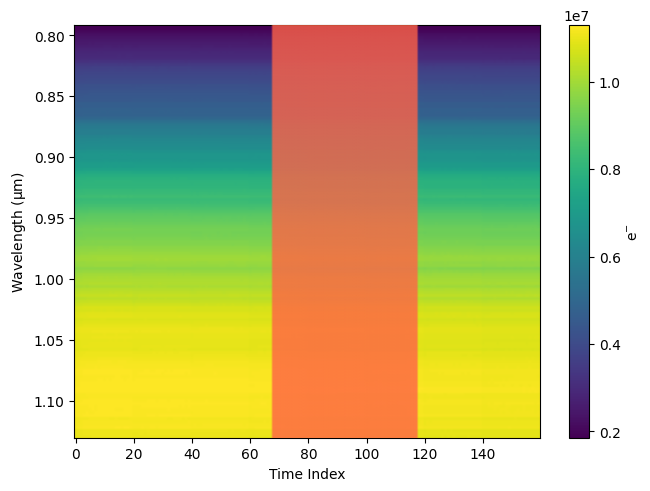

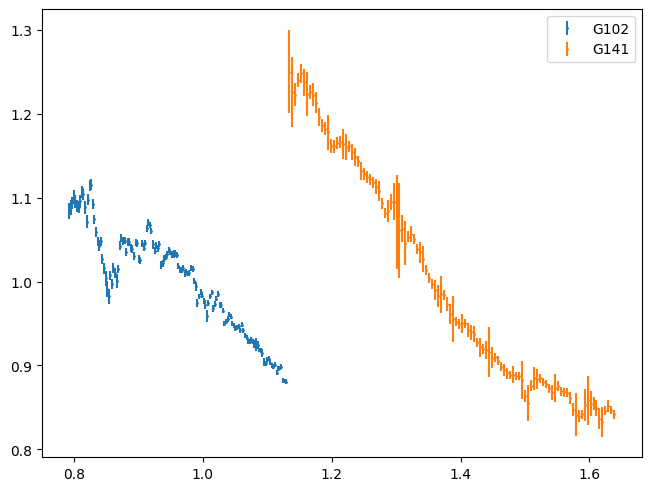

<Figure size 640x480 with 0 Axes>

In [13]:
visit = 'S22'

# bin_edges = S22_speclc_bin_edges 
err_factor = S22_SED_err_factor
# speclc_err_factor = S22_speclc_err_factor

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

assert(len(err_factor)==len(speclc_rainbow.wavelength))

'Adjust uncertainties and bin the rainbow'
for i in range(len(rainbow.wavelength.value)):
    speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] * err_factor[i]

'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )

out_of_transit.imshow()
'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
calibrated_mean_spec_G102 = jnp.array(calibrated_mean_spec)
oot_spec_err_G102 = jnp.array(oot_spec_err)
SED_wavelengths_G102 = jnp.array(_SED_wavelengths)

visit = 'F21'
# bin_edges = F21_speclc_bin_edges 
err_factor = F21_SED_err_factor
# speclc_err_factor = F21_speclc_err_factor

'Things that automatically get re-defined for either visit'
predicted_T0 = visits[f'{visit}']['T0 (BJD_TDB)'].value
binwidth = visits[f'{visit}']['native resolution']
exptime = visits[f'{visit}']['exp (s)']
grism = visits[f'{visit}']['Grism']
rainbow = read_rainbow(f"../../data/rainbows/{visit}_scan-combined_trimmed_pacman_spec.rainbow.npy")
speclc_rainbow = rainbow

assert(len(err_factor)==len(speclc_rainbow.wavelength))

'Adjust uncertainties and bin the rainbow'
for i in range(len(rainbow.wavelength.value)):
    speclc_rainbow.uncertainty[i,:] = rainbow.uncertainty[i,:] * err_factor[i]

'remove the transit'
out_of_transit = ( speclc_rainbow.trim().mask_transit(period=8.463*u.day, t0=predicted_T0*u.day, duration=0.15*u.day) )

'define the appropriate arrays'
_meanOOTspec = out_of_transit.get_average_spectrum_as_rainbow()
meanOOTspec = _meanOOTspec.flux
meanOOTspec_relative_err = _meanOOTspec.uncertainty.value/meanOOTspec.value
_oot_spec_err = meanOOTspec_relative_err.flatten()
_SED_wavelengths = (_meanOOTspec.wavelength.value).flatten()
e_per_s = meanOOTspec / exptime
e_per_s_per_angstrom = e_per_s / binwidth
_w, _s, _e = read_sensitivity_curve(grism=grism)
binned_filter_response = bintogrid(_w.value, _s.value, newx=_SED_wavelengths)['y'] * u.cm**2 / u.erg
_calibrated_mean_spec = e_per_s_per_angstrom.flatten() / binned_filter_response
calibrated_mean_spec = _calibrated_mean_spec.value/np.nanmean(_calibrated_mean_spec.value)
oot_spec_err = _oot_spec_err * calibrated_mean_spec

# Convert to JAX arrays
calibrated_mean_spec_G141 = jnp.array(calibrated_mean_spec)
oot_spec_err_G141 = jnp.array(oot_spec_err)
SED_wavelengths_G141 = jnp.array(_SED_wavelengths)

plt.figure()
plt.errorbar(SED_wavelengths_G102,calibrated_mean_spec_G102,yerr=oot_spec_err_G102*100,fmt='o',label='G102',ms=1)
plt.errorbar(SED_wavelengths_G141,calibrated_mean_spec_G141,yerr=oot_spec_err_G141*100,fmt='o',label='G141',ms=1)
plt.legend()
plt.show()
plt.clf()

In [14]:
rng_seed = 0

def hstack_recursive(final_states, checkpoint_states):
    for key in final_states.keys():
        if isinstance(final_states[key], dict):
            hstack_recursive(final_states[key], checkpoint_states[key])
        else:
            final_states[key] = jnp.hstack([
                final_states[key], 
                checkpoint_states[key]
            ])

def print_big_message(big_message):
    print('\n\n')
    print('=' * len(big_message))
    print(big_message)
    print('=' * len(big_message))
    print('\n\n')

def post_batch_viz_save(self, **kwargs):
    """
    here we define some tasks to do after each completed checkpoint:
    """
    print(f'Corner for checkpoint {self.checkpoint}')

    samples_cumulative = self.get_samples()
    corner.corner(samples_cumulative)
    plt.suptitle(f'checkpoint {self.checkpoint}')
    plt.savefig(f'../../figs/{visit}_chkpt_{self.checkpoint}_whitelight_corner.png',dpi=200)
    plt.show()
    plt.clf()
    
    # EXTRACT MEDIAN PARAMETERS DIRECTLY FROM SAMPLES (like corner plot does)
    chkpt_median_params = {}
    for param_name, param_samples in samples_cumulative.items():
        # param_samples has shape (num_chains, num_samples)
        # Flatten across chains and compute median
        flattened_samples = param_samples.flatten()
        chkpt_median_params[param_name] = float(jnp.median(flattened_samples))
    
    print("Median parameters from samples:")
    for param, value in chkpt_median_params.items():
        print(f"  {param}: {value:.6f}")

    # result = arviz.from_numpyro(self)
    # display(arviz.summary(result))

    # checkpoint_model, checkpoint_star = plot_results(chkpt_median_params,figlabel=f'chkpt_{self.checkpoint}')

    with open(f'../../data/samples/samples_cumulative_{self.start_time}_checkpoint_{self.checkpoint:04d}.pkl', 'wb') as file:
        pickle.dump(dict(samples_cumulative), file)

class MCMCWithCheckpoints(MCMC):
    running_states = None
    checkpoint = 0
    start_time = None
    
    def run_checkpoints(self, rng_key, *args, extra_fields=(), n_checkpoints=10, 
                        progress_bar_warmup=True, progress_bar_samples=True, 
                        init_params=None, on_checkpoint=None, **kwargs):
        """
        Run the MCMC samplers and collect samples.

        :param random.PRNGKey rng_key: Random number generator key to be used for the sampling.
            For multi-chains, a batch of `num_chains` keys can be supplied. If `rng_key`
            does not have batch_size, it will be split in to a batch of `num_chains` keys.
        :param args: Arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init` method.
            These are typically the arguments needed by the `model`.
        :param extra_fields: Extra fields (aside from `"z"`, `"diverging"`) from the
            state object (e.g. :data:`numpyro.infer.hmc.HMCState` for HMC) to be collected
            during the MCMC run. Note that subfields can be accessed using dots, e.g.
            `"adapt_state.step_size"` can be used to collect step sizes at each step. Exclude sample sites from
            collection with "~`sampler.sample_field`.`sample_site`". e.g. "~z.a" will prevent site "a" from
            being collected if you're using the NUTS sampler. To collect samples of a site "a" in the
            unconstrained space, we can specify the variable here, e.g. `extra_fields=("z.a",)`.
        :type extra_fields: tuple or list of str
        :param init_params: Initial parameters to begin sampling. The type must be consistent
            with the input type to `potential_fn` provided to the kernel. If the kernel is
            instantiated by a numpyro model, the initial parameters here correspond to latent
            values in unconstrained space.
        :param kwargs: Keyword arguments to be provided to the :meth:`numpyro.infer.mcmc.MCMCKernel.init`
            method. These are typically the keyword arguments needed by the `model`.

        .. note:: jax allows python code to continue even when the compiled code has not finished yet.
            This can cause troubles when trying to profile the code for speed.
            See https://jax.readthedocs.io/en/latest/async_dispatch.html and
            https://jax.readthedocs.io/en/latest/profiling.html for pointers on profiling jax programs.
        """
        self.start_time = datetime.now().strftime("%Y-%m-%d_%H-%M")
        num_warmup_total = int(self.num_warmup)
        num_samples_total = int(self.num_samples)
        
        check_point_indices = [
            jnp.arange(num_warmup_total), 
            *jnp.array_split(jnp.arange(num_samples_total), n_checkpoints)
        ]
        n_checkpoints = len(check_point_indices)
        rng_keys = random.split(rng_key, n_checkpoints)
        pbar = tqdm(enumerate(zip(rng_keys, check_point_indices)), total=n_checkpoints)
        for checkpoint, (rng_key, bounds) in pbar:
            if checkpoint == 0:
                self.progress_bar = progress_bar_warmup
                pbar.set_description('Run warmup')
                print_big_message("Begin warmup")
                self.warmup(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)
                print_big_message(f"Begin {num_samples_total} samples with {n_checkpoints} checkpoints")

            else:
                pbar.set_description(f'Run samples {bounds.min()} to {bounds.max()}')

                self.progress_bar = progress_bar_samples
                self.num_samples = bounds.size
                self.run(rng_key, *args, extra_fields=extra_fields, init_params=init_params, **kwargs)

                # add to running states:
                if self.running_states is None:
                    self.running_states = dict(self._states)
                else:
                    hstack_recursive(self.running_states, self._states)
                
                # ensure that calls to `self.get_samples` will build a new samples array
                # out of the running states:
                self._states_flat = None
                self._states = self.running_states

                if on_checkpoint is not None:
                    on_checkpoint(self, **kwargs)
                self.checkpoint += 1
        
        pbar.close()

        # reset to total number for arviz IO
        self.num_samples = num_samples_total

  0%|          | 0/3 [00:00<?, ?it/s]




Begin warmup





  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

  0%|          | 0/500 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Corner for checkpoint 0


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


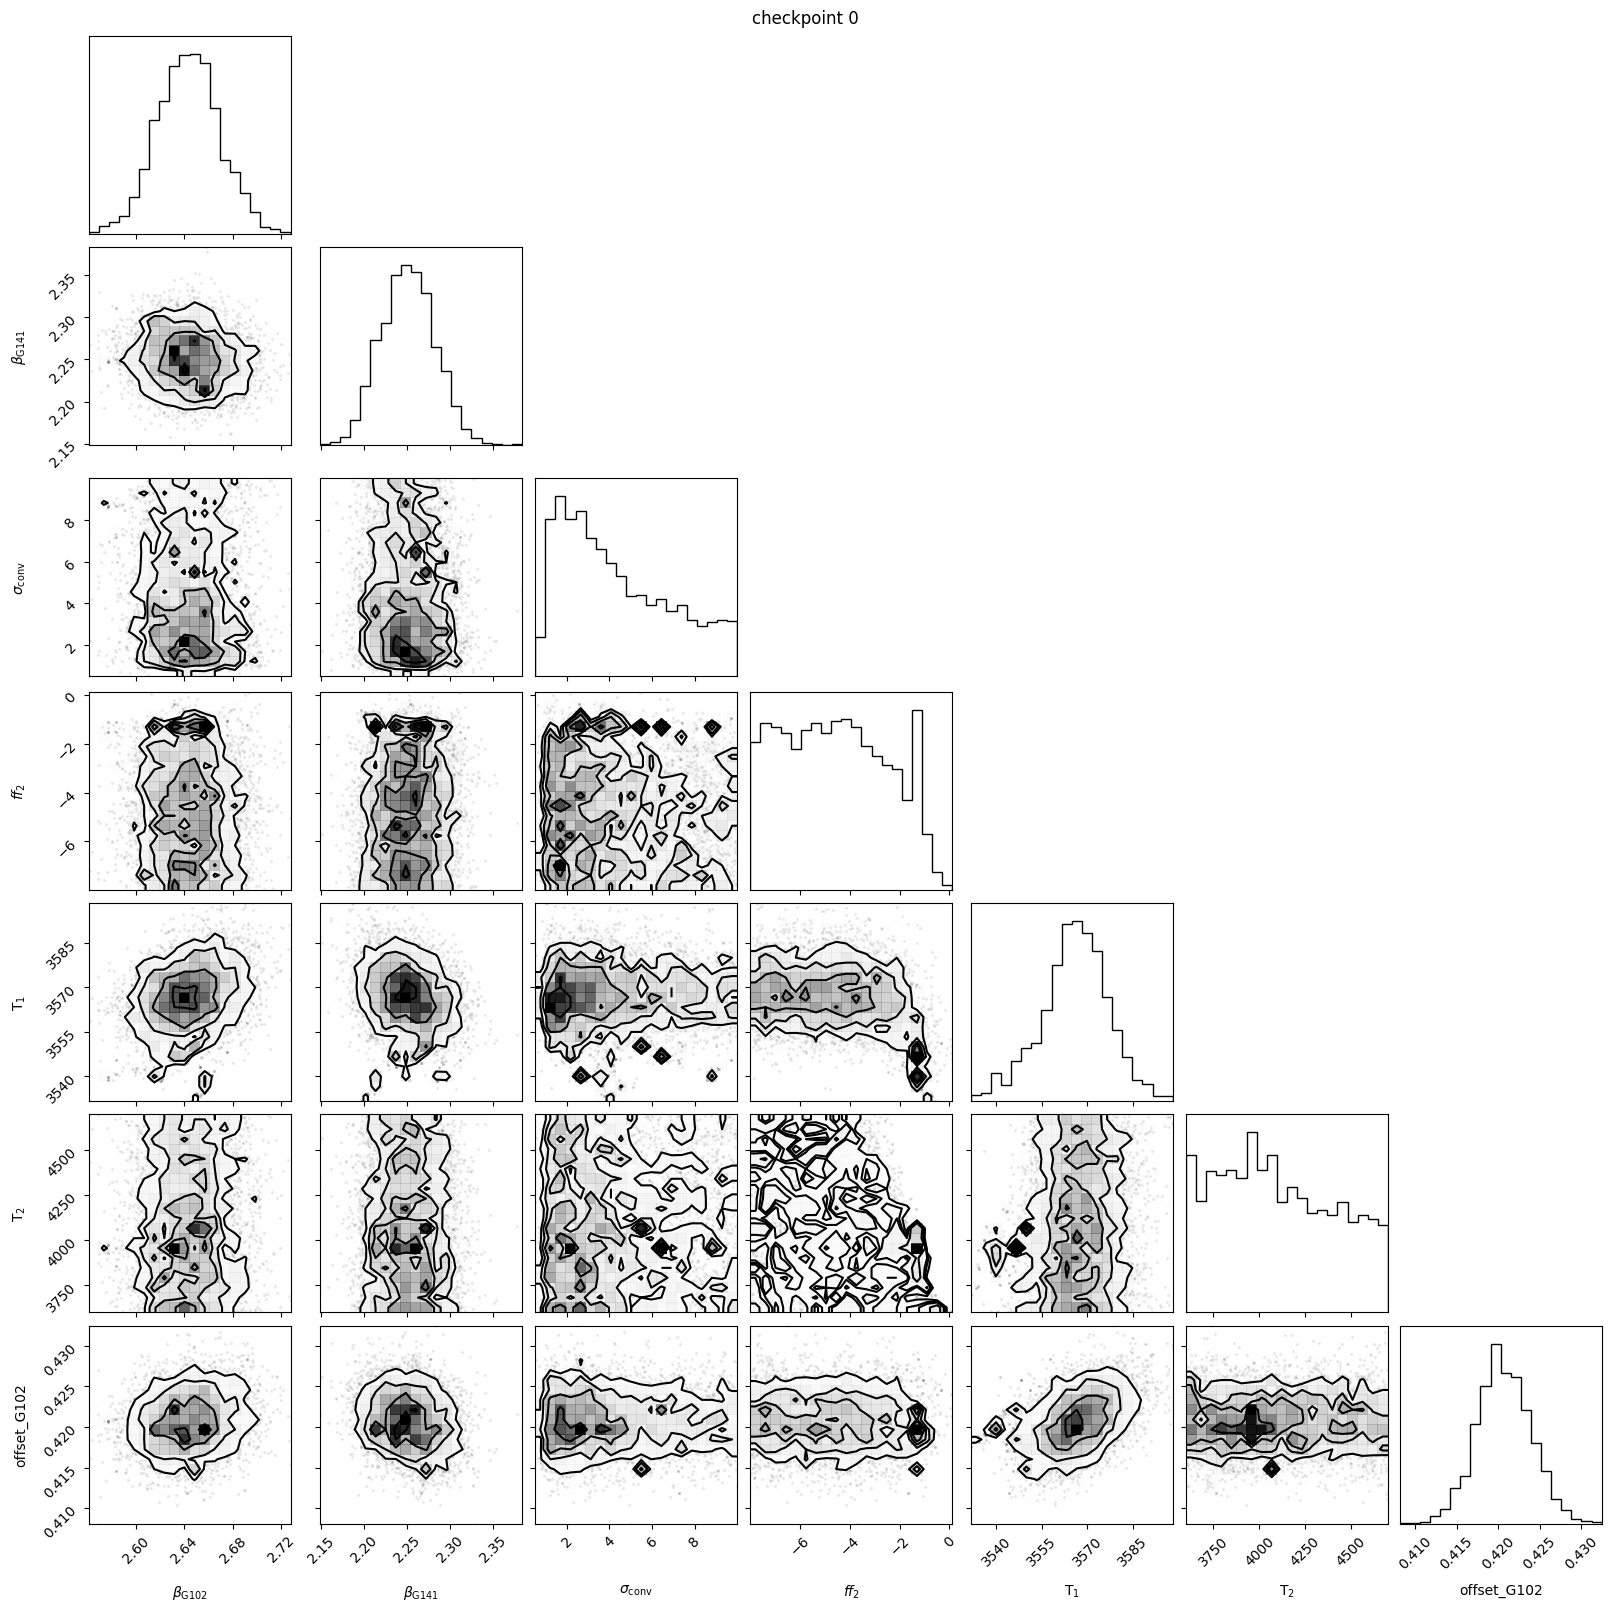

Median parameters from samples:
  $\beta_{\rm G102}$: 2.643281
  $\beta_{\rm G141}$: 2.250720
  $\sigma_{\rm conv}$: 3.755552
  $ff_2$: -4.587227
  T$_1$: 3566.209706
  T$_2$: 4061.462040
  offset_G102: 0.420576


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Corner for checkpoint 1


/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


<Figure size 640x480 with 0 Axes>

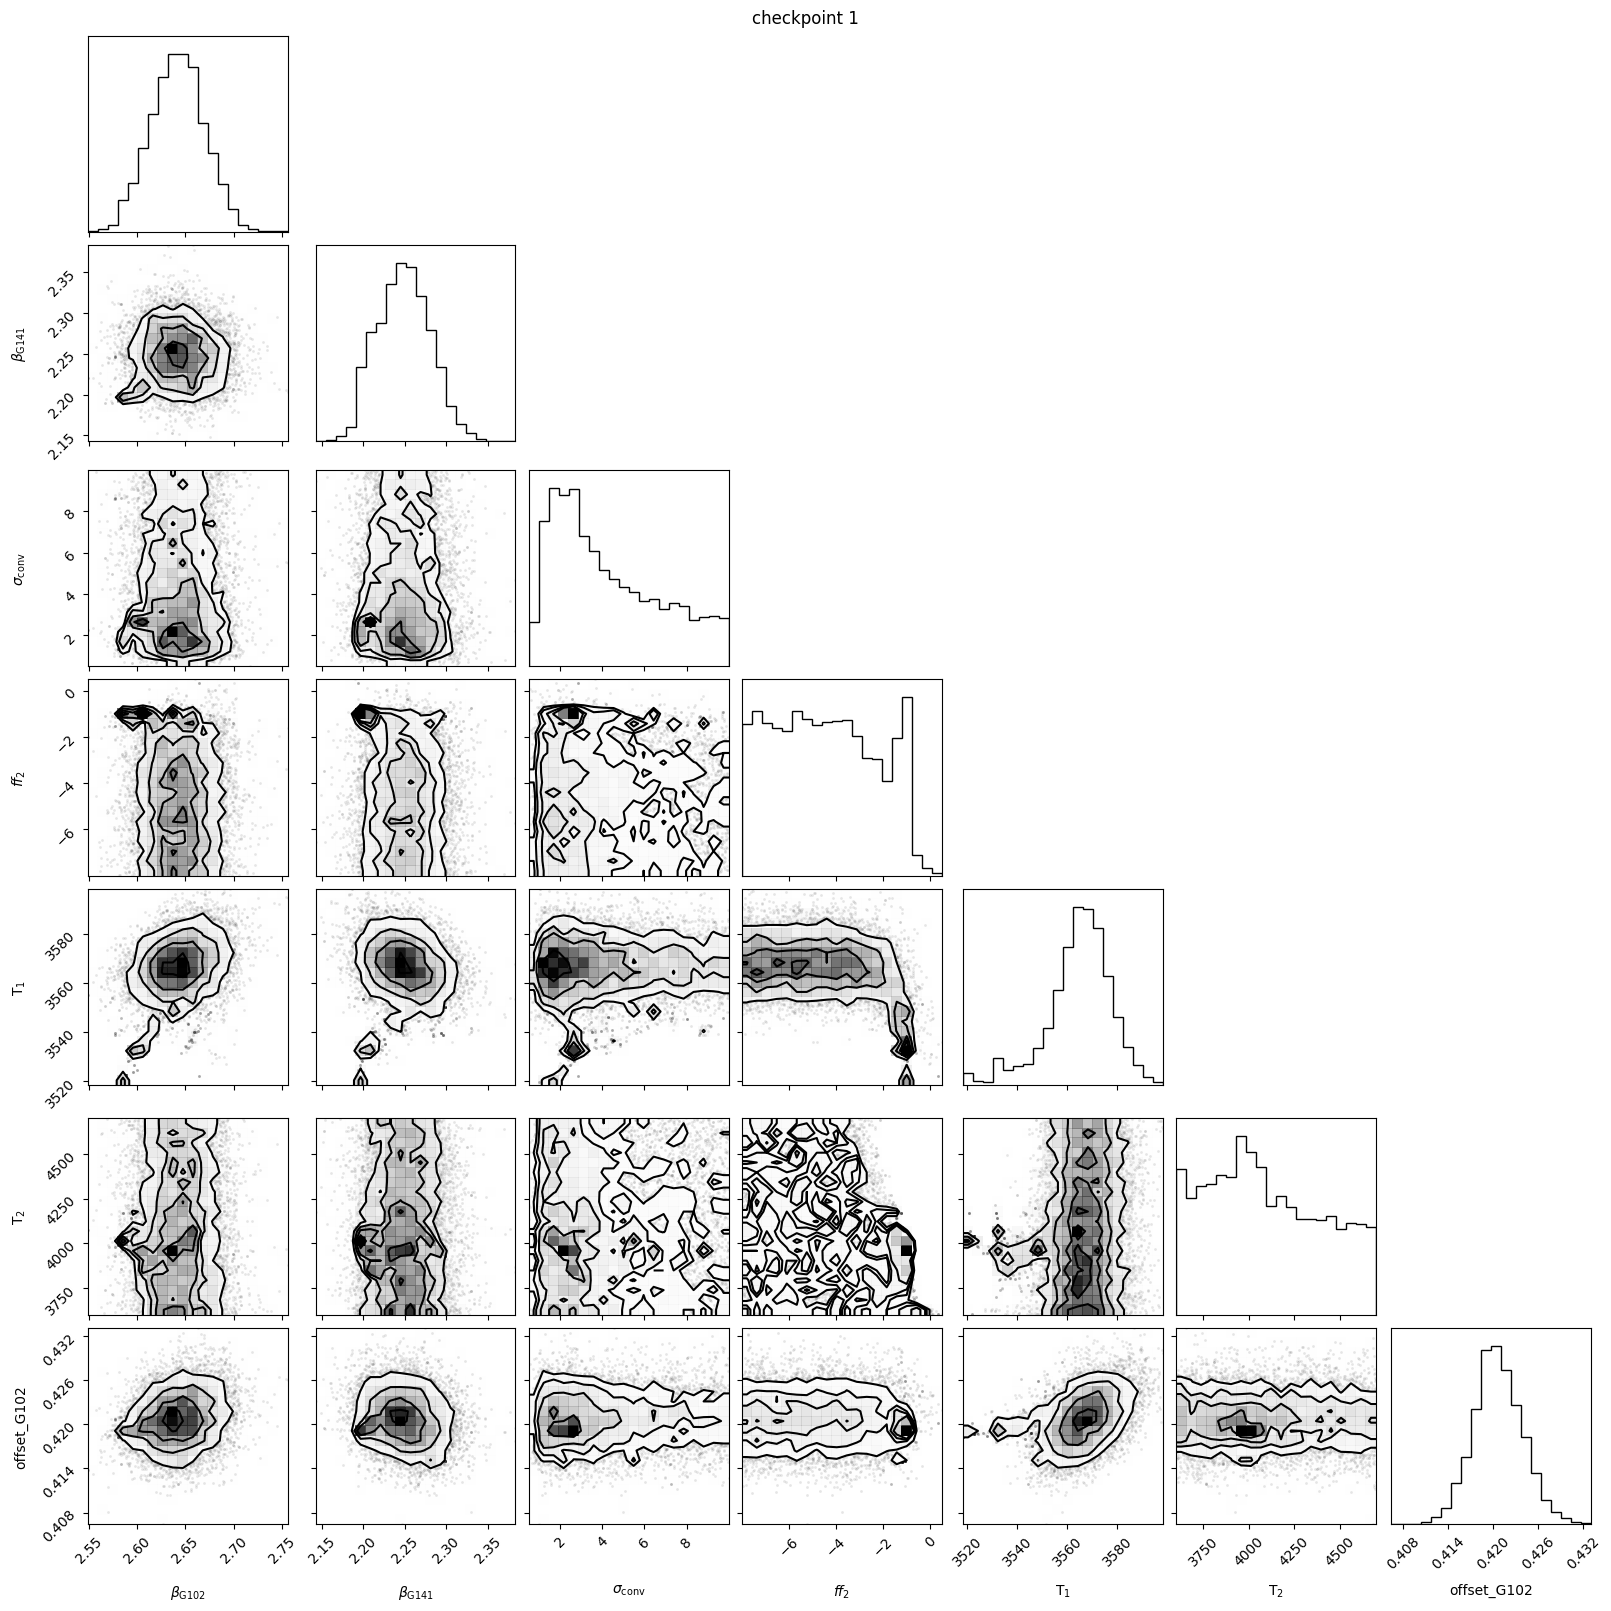

Median parameters from samples:
  $\beta_{\rm G102}$: 2.642037
  $\beta_{\rm G141}$: 2.247846
  $\sigma_{\rm conv}$: 3.585222
  $ff_2$: -4.549307
  T$_1$: 3565.927791
  T$_2$: 4056.760886
  offset_G102: 0.420520

                           mean       std    median      5.0%     95.0%     n_eff     r_hat
   $\beta_{\rm G102}$      2.64      0.03      2.64      2.59      2.69    167.06      1.02
   $\beta_{\rm G141}$      2.25      0.03      2.25      2.20      2.30    172.68      1.02
  $\sigma_{\rm conv}$      4.25      2.52      3.59      0.83      8.39   1304.42      1.01
               $ff_2$     -4.46      2.12     -4.55     -7.42     -0.94    150.50      1.03
                T$_1$   3564.57     12.98   3565.93   3545.19   3586.44     34.74      1.07
                T$_2$   4097.17    305.89   4056.76   3600.90   4555.67   3796.88      1.00
          offset_G102      0.42      0.00      0.42      0.42      0.43   2919.08      1.00

Number of divergences: 591


<Figure size 640x480 with 0 Axes>

In [15]:
n_temps = 1
n_warmup = 5_00
n_samples = 2_000
n_chains = 4
n_check = 2

model_designation = f'jointvisit_{n_temps}T_{n_samples}_{n_chains}chains_SED-omitcoldtemp'

rng_key = PRNGKey(32)

sampler = NUTS(
    numpyro_model,
    dense_mass=True
    )

mcmc = MCMCWithCheckpoints(
    sampler, 
    num_warmup=n_warmup, 
    num_samples=n_samples,
    num_chains=n_chains
)

mcmc.run_checkpoints(rng_key, n_checkpoints=n_check, on_checkpoint=post_batch_viz_save)

mcmc.print_summary()                                                                        

# arviz converts a numpyro MCMC object to an `InferenceData` object based on xarray:
result = arviz.from_numpyro(mcmc)

# Post-Inference Analysis

In [6]:
'Save the result'
result.to_netcdf(f'../../data/samples/{model_designation}')

'Print the summary'
arviz.summary(result)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
$\beta_{\rm G102}$,2.644,0.027,2.595,2.696,0.001,0.000,2345.0,1831.0,1.00
$\beta_{\rm G141}$,2.251,0.032,2.195,2.313,0.001,0.000,2045.0,2782.0,1.00
$\sigma_{\rm conv}$,4.423,2.602,0.822,9.335,0.087,0.048,787.0,470.0,1.00
$ff_2$,-4.062,1.879,-7.000,-1.080,0.074,0.042,592.0,364.0,1.01
T$_1$,3562.945,26.698,3540.866,3587.901,1.441,8.981,811.0,147.0,1.01
T$_2$,4075.661,312.780,3600.001,4603.624,6.215,3.258,2412.0,1950.0,1.00
offset_G102,0.421,0.003,0.415,0.427,0.000,0.000,3225.0,3248.0,1.00


In [7]:
'Examine the Leave-One-Out (LOO) summary'
loo = arviz.loo(result, pointwise=True)
loo

Computed from 8000 posterior samples and 248 observations log-likelihood matrix.

         Estimate       SE
elpd_loo   640.44    11.79
p_loo        4.81        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      248  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

In [8]:
'Extract median result'
median_params = arviz.summary(result,stat_focus='median')['median']

/opt/anaconda3/envs/pyjax312/lib/python3.12/site-packages/corner/core.py:133: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(


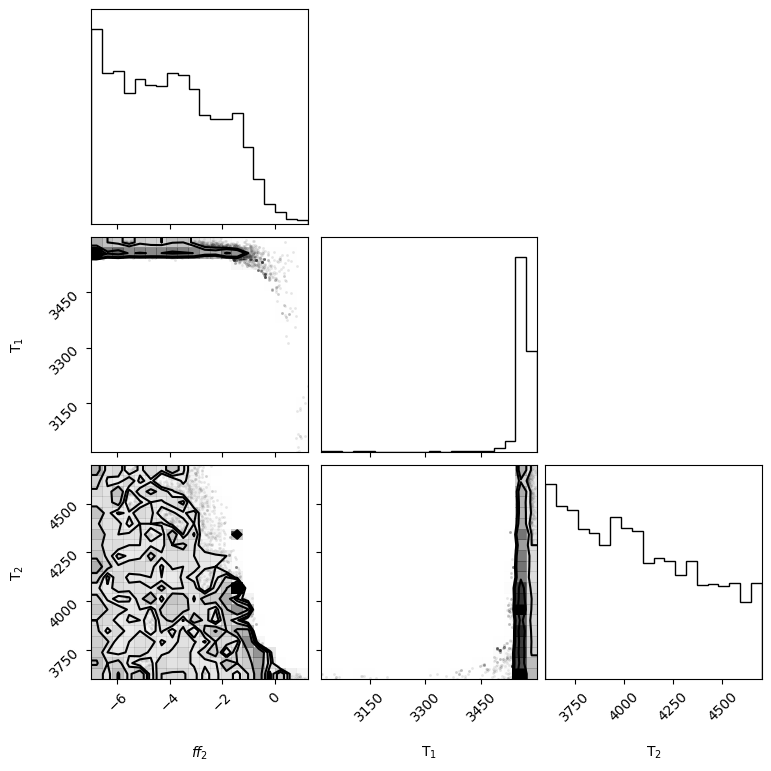

In [9]:
'Make a corner plot'
corner.corner(
    result, var_names=['~offset_G102',
                       r'~$\beta_{\rm G102}$',
                       r'~$\beta_{\rm G141}$',
                       r'~$\sigma_{\rm conv}$'],
    # quiet=True, 
);
plt.savefig(f'../../figs/{model_designation}_corner.png',dpi=200)

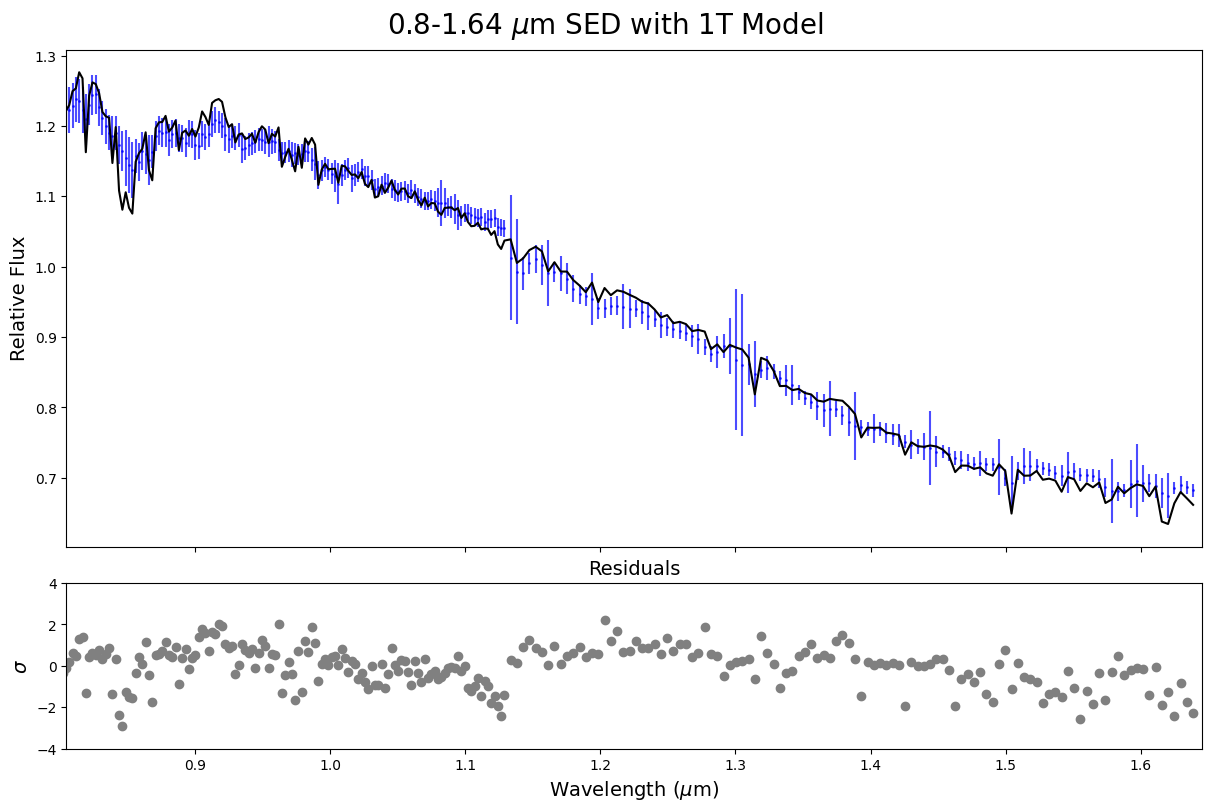

In [10]:
'Plot the data, model, and residuals'

_spec_flux_jax = jnp.concatenate([jnp.array(calibrated_mean_spec_G102+jnp.asarray(median_params['offset_G102'],dtype=jnp.float64)),
                                         jnp.array(calibrated_mean_spec_G141)])
median_spec_flux = _spec_flux_jax/jnp.mean(_spec_flux_jax)
median_spec_err = jnp.concatenate([jnp.array(oot_spec_err_G102*jnp.asarray(10**median_params[r'$\beta_{\rm G102}$'],dtype=jnp.float64)),
                                jnp.array(oot_spec_err_G141*jnp.asarray(10**median_params[r'$\beta_{\rm G141}$'],dtype=jnp.float64))])
combined_SED_wavelengths = jnp.concatenate([jnp.array(SED_wavelengths_G102),jnp.array(SED_wavelengths_G141)])

filter_sigma = jnp.asarray(median_params[r'$\sigma_{\rm conv}$'], dtype=jnp.float64)
T_1 = jnp.asarray(median_params['T$_1$'], dtype=jnp.float64)
T_2 = jnp.asarray(median_params['T$_2$'], dtype=jnp.float64)
# T_3 = jnp.asarray(median_params['T$_3$'], dtype=jnp.float64)

spec_1, spec_2 = [
    get_BTSettl_spectrum_jax(T=Temp)
    for Temp in [T_1,T_2] ]
# spec_1, spec_2, spec_3, = [
#     get_BTSettl_spectrum_jax(T=Temp)
#     for Temp in [T_1,T_2,T_3] ]

# spec_1 = get_BTSettl_spectrum_jax(T=T_1)

# f1 = jnp.asarray(10**median_params[r'$ff_1$'],dtype=jnp.float64)
f2 = jnp.asarray(10**median_params[r'$ff_2$'],dtype=jnp.float64)
# f3 = 1.0
# _median_flux = (c1*spec_1[1] + c2*spec_2[1] + c3*spec_3[1])
_median_flux = (1.0*spec_1[1] + f2*spec_2[1])
# _median_flux = 1.0*spec_1[1]
_model_flux = _median_flux/jnp.mean(_median_flux)
convolved = convolve_spectrum_jax(panchromatic_wavelengths, _model_flux, sigma=filter_sigma)
binned_model_flux = shone.bin_spectrum(combined_SED_wavelengths, panchromatic_wavelengths, convolved)
median_model_flux = (binned_model_flux/jnp.mean(binned_model_flux))

fig,axs = plt.subplots(2,1,figsize=(12,8),sharex=True,gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle(r'0.8-1.64 $\mu$m SED with '+f'{n_temps}T Model',fontsize=20)
axs[1].set_title('Residuals',fontsize=14)
axs[1].set_xlim(0.805,1.645)
axs[1].set_ylim(-4,4)
axs[1].set_xlabel(r'Wavelength ($\mu$m)',fontsize=14)
axs[0].set_ylabel('Relative Flux',fontsize=14)
axs[1].set_ylabel(r'$\sigma$',fontsize=14)

axs[0].errorbar(combined_SED_wavelengths,
                median_spec_flux,
                yerr=median_spec_err,
                fmt='o',color='b',ms=1,alpha=0.7)
axs[0].plot(combined_SED_wavelengths,
                median_model_flux,color='k',zorder=100)
axs[1].scatter(combined_SED_wavelengths,(median_model_flux-median_spec_flux)/median_spec_err,color='gray')

plt.savefig(f'../../figs/{model_designation}_result.png',dpi=200)

# Compare multiple models of the same dataset

In [11]:
# compare_dict = {}

# compare_dict['model_1'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_1000_11chains_SED_separatebetas')
# compare_dict['model_2'] = arviz.InferenceData.from_netcdf('../../data/samples/jointvisit_3T_1000_14chains_SED_photonerrs')
# # compare_dict['model_3'] = arviz.InferenceData.from_netcdf('../../data/samples/')

# arviz.compare(compare_dict)

From https://num.pyro.ai/en/latest/tutorials/bad_posterior_geometry.html

In general it is difficult to assess whether the samples returned from HMC or NUTS represent accurate (approximate) samples from the posterior. Two general rules of thumb, however, are to look at the effective sample size (ESS) and r_hat diagnostics returned by mcmc.print_summary(). If we see values of r_hat in the range (1.0, 1.05) and effective sample sizes that are comparable to the total number of samples num_samples (assuming thinning=1) then we have good reason to believe that HMC is doing a good job. If, however, we see low effective sample sizes or large r_hats for some of the variables (e.g. r_hat = 1.15) then HMC is likely struggling with the posterior geometry. In the following we will use r_hat as our primary diagnostic metric.